# Autoencoders Exercise

## Imports

In [1]:
import kagglehub
import os
import torch
from torch import nn
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split

## Loading Data from Kaggle

In [2]:
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
img_dir = os.path.join(path, "img_align_celeba", "img_align_celeba")

Using Colab cache for faster access to the 'celeba-dataset' dataset.


In [3]:
class CelebASubset(Dataset):
    def __init__(self, img_dir, num_images=10000, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        todas_imagens = os.listdir(img_dir)
        self.images = todas_imagens[:num_images]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

## Applying the transformations and Creating the Dataset and Dataloader

In [4]:
transform = T.Compose([
    T.Resize(size=(80,80)),
    T.ToTensor()
    ]

)

In [5]:
dataset = CelebASubset(img_dir,transform=transform)
size = len(dataset)
train_size = int(0.85*size)
val_size = size - train_size

In [6]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [7]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)

## VAEs Parameters

In [8]:
latent_size = 200
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=512,kernel_size=(4,4), stride=2, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(512),
            nn.Dropout(0.4),
            nn.Conv2d(in_channels=512,out_channels=256,kernel_size=(4,4),stride=2, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(256),
            nn.Dropout(0.3),
            nn.Conv2d(in_channels=256,out_channels=128,kernel_size=(4,4),stride=2, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(128),
            nn.Dropout(0.2),
        )

        flattened_size = 128*10*10

        self.FC_input = nn.Linear(flattened_size, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear(hidden_dim, latent_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)


    def forward(self, x):
        h_       = self.layers(x)
        h_       = self.flatten(h_)
        h_       = self.LeakyReLU(self.FC_input(h_))
        mean     = self.FC_mean(h_)
        log_var  = self.FC_var(h_)                     # encoder produces mean and log of variance
                                                       #             (i.e., parateters of simple tractable normal distribution "q"

        return mean, log_var


In [10]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        self.expand = nn.Linear(latent_size, 128*10*10)

        self.layers = nn.Sequential(
            nn.ConvTranspose2d(128,64,kernel_size=(4,4),stride=2, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64,32,kernel_size=(4,4),stride=2, padding=1),
            nn.LeakyReLU(),
            nn.BatchNorm2d(32),
            nn.ConvTranspose2d(32,3,kernel_size=(4,4),stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h     = self.expand(x)
        h     = h.view(-1,128,10,10)
        x_hat     = self.layers(h)

        return x_hat

In [11]:
class VAE(nn.Module):
  def __init__(self, Encoder, Decoder):
    super(VAE, self).__init__()
    self.encoder = Encoder
    self.decoder = Decoder

  # give a point inside of the mean and variância to the decoder works
  def reparameterization(self, mean, log_var): #Delivery the mean and variância
    std = torch.exp(0.5*log_var)
    epsilon = torch.randn_like(std).to(device)
    z = mean + (std*epsilon)
    return z

  def forward(self,x):
    mean, log_var = self.encoder(x)
    z = self.reparameterization(mean, log_var)
    ans = self.decoder(z)
    return ans, mean, log_var


In [12]:
encoder = Encoder(input_dim=3,hidden_dim=100,latent_dim=200)
decoder = Decoder(latent_dim=200,hidden_dim=100,output_dim=3)
model = VAE(encoder,decoder).to(device)

In [13]:
lossfunc = nn.MSELoss()
otpim = torch.optim.Adam(model.parameters(), lr = 0.001)

In [14]:
def vae_loss(x_hat, x, mean, log_var):
  rec_loss = torch.nn.functional.mse_loss(x_hat, x, reduction='sum')
  kld = -0.5*torch.sum(1+log_var - mean.pow(2) - log_var.exp())
  return rec_loss + kld

In [15]:
def train(dataloader, model, lossfunc, optimizer):
  model.train()
  cumloss = 0.0
  for data in dataloader:
    data = data.to(device)
    x_hat, mean, log_var = model(data)

    optimizer.zero_grad()
    loss = lossfunc(x_hat, data, mean, log_var)
    cumloss += loss.item()
    loss.backward()
    optimizer.step()

  mean_error = cumloss/len(dataloader)
  return mean_error


def test(dataloader, model, lossfunc):
  cumloss = 0.0
  model.eval()
  real_images = None
  gen_images = None
  with torch.no_grad():
    for i, data in enumerate(dataloader):
      data = data.to(device)
      x_hat, mean, log_var = model(data) #x_hat é a estimativa da nova imagem

      loss = lossfunc(x_hat, data, mean, log_var)
      cumloss += loss.item()
      if i == 0:
        real_images = data.cpu()
        gen_images = x_hat.cpu()

  mean_error = cumloss/len(dataloader)
  return mean_error, real_images, gen_images






In [39]:
epochs = 100
for i in range(epochs):
  train_loss = train(train_dataloader,model,vae_loss,otpim)
  if i % 5 == 0:
    print(f'Epoch {i+1} - Error: {train_loss}')

test_loss, real_images, gen_images = test(val_dataloader, model, vae_loss)

Epoch 1 - Error: 9801.868325599155
Epoch 6 - Error: 9607.505672139332
Epoch 11 - Error: 9446.7797704711
Epoch 16 - Error: 9300.878597861842
Epoch 21 - Error: 9227.686483053336
Epoch 26 - Error: 9011.7036279664
Epoch 31 - Error: 8912.725905339521
Epoch 36 - Error: 8813.436954813793
Epoch 41 - Error: 8759.036261307565
Epoch 46 - Error: 8701.454911081415
Epoch 51 - Error: 8627.995607304394
Epoch 56 - Error: 8598.046195811796
Epoch 61 - Error: 8556.3381421082
Epoch 66 - Error: 8458.069146866188
Epoch 71 - Error: 8443.855248472744
Epoch 76 - Error: 8403.142644208177
Epoch 81 - Error: 8343.948236680568
Epoch 86 - Error: 8297.01226026492
Epoch 91 - Error: 8251.858725182095
Epoch 96 - Error: 8217.66044077479


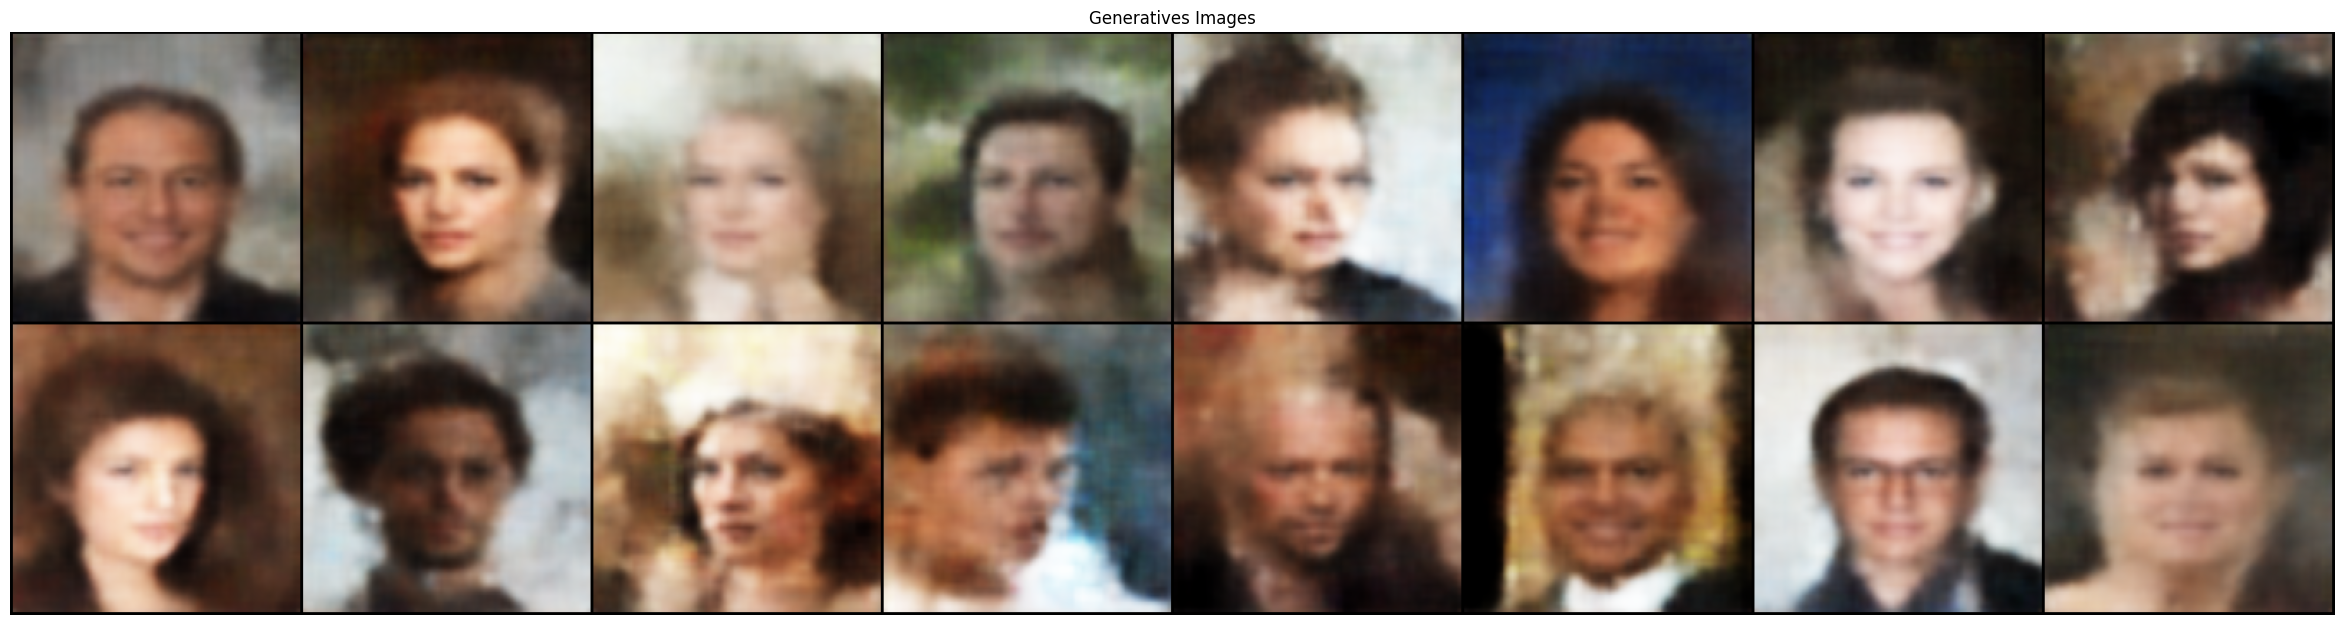

In [54]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np

transform2 = T.Compose([
    T.Resize(size=(200,200))
])

res_image = gen_images[:16]
new_img = transform2(res_image)

plt.figure(figsize=(30, 30))
plt.subplot(2, 1, 1)
plt.axis("off")
plt.title("Generatives Images")
plt.imshow(np.transpose(vutils.make_grid(new_img, normalize=True).numpy(), (1, 2, 0)))
plt.show()